# RQ5 – Governance Risk Scoring

Combines cybersecurity model monitoring with the provided CO2 dataset for sustainability/compliance governance scoring.

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

OUTPUT_DIR = "responsible_ai_outputs"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables_csv")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_pdf")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(possible_names):
    """Find uploaded dataset in current folder, /mnt/data, or Kaggle input folders."""
    search_roots = [".", "/mnt/data", "/kaggle/input"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for name in possible_names:
            matches = glob.glob(os.path.join(root, "**", name), recursive=True)
            if matches:
                return matches[0]

    all_csvs = []
    for root in search_roots:
        if os.path.exists(root):
            all_csvs += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    for f in all_csvs:
        base = os.path.basename(f).lower()
        for name in possible_names:
            token = name.replace("(1)", "").replace(".csv","").lower()
            if token in base:
                return f
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

CYBER_FILE = find_file([
    "cybersecurity_intrusion_data(1).csv",
    "cybersecurity_intrusion_data.csv"
])
cyber = pd.read_csv(CYBER_FILE)

target_col = "attack_detected"
drop_cols = ["session_id"]
cyber = cyber.drop(columns=[c for c in drop_cols if c in cyber.columns])

X = cyber.drop(columns=[target_col])
y = cyber[target_col].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
}
print("Loaded:", CYBER_FILE)
print("Dataset shape:", cyber.shape)
print("Metrics:", metrics)

def save_bar(df, x, y, title, xlabel, ylabel, filename, rotation=30):
    plt.figure(figsize=(8, 4.8))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)


# Load sustainability / CO2 dataset
CO2_FILE = find_file([
    "Data(1).csv",
    "Data.csv"
])
co2 = pd.read_csv(CO2_FILE)
print("Loaded CO2 dataset:", CO2_FILE)
print("CO2 dataset shape:", co2.shape)

Loaded: ./cybersecurity_intrusion_data.csv
Dataset shape: (9537, 10)
Metrics: {'accuracy': 0.8846960167714885, 'precision': 1.0, 'recall': 0.7420262664165104, 'f1': 0.8519116855142703}
Loaded CO2 dataset: ./Data.csv
CO2 dataset shape: (43746, 80)


Saved table: responsible_ai_outputs/tables_csv/RQ5_governance_risk_scoring.csv


,Governance_Metric,Score,Interpretation
0,Explainability,99.14,Higher is better
1,Fairness,89.42,Higher is better
2,Stability,88.47,Higher is better
3,Drift Control,98.93,Higher is better
4,Sustainability/Compliance,90.83,Higher is better
5,Overall Risk,6.64,Low Risk


,Dashboard_Card,Value
0,Model Accuracy,88.47%
1,Fairness Score,89.42%
2,Latest Drift Score,0.0043
3,Explainability Score,99.14%
4,Sustainability/Compliance,90.83%
5,Overall Risk Score,6.64/100 (Low Risk)


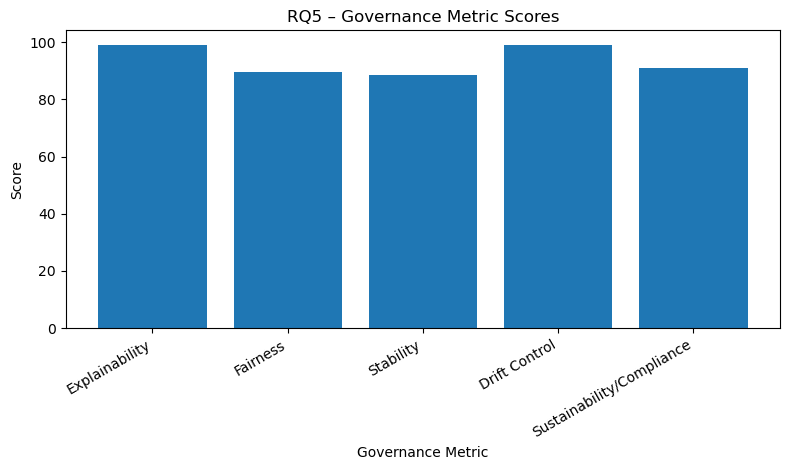

Saved figure: responsible_ai_outputs/figures_pdf/RQ5_governance_metric_scores.pdf


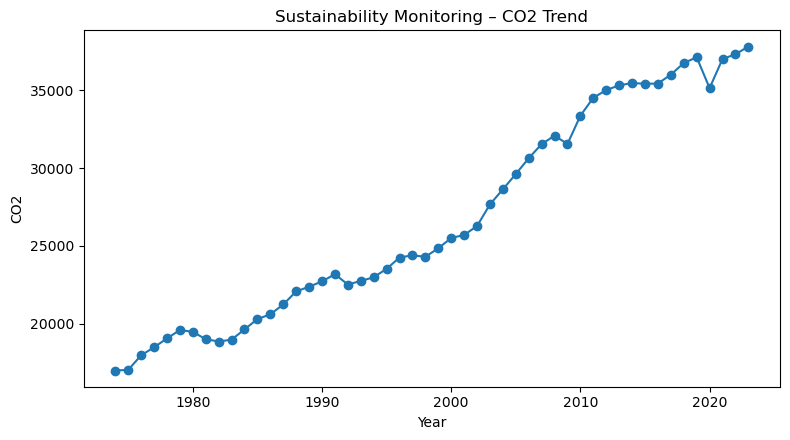

Saved sustainability figure: responsible_ai_outputs/figures_pdf/RQ5_sustainability_co2_trend.pdf


In [2]:
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
rf = clf.named_steps["model"]
importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
top5_share = importance.head(5).sum()
explainability_score = min(100, round(70 + top5_share * 30, 2))

test_df = X_test.copy()
test_df["actual_attack"] = y_test.values
test_df["predicted_attack"] = pred

fairness_scores = []
for col in [c for c in ["protocol_type", "encryption_used", "browser_type", "unusual_time_access"] if c in test_df.columns]:
    for _, g in test_df.groupby(col):
        if len(g) >= 20:
            fairness_scores.append(1 - abs(g["predicted_attack"].mean() - g["actual_attack"].mean()))
fairness_score = round(float(np.mean(fairness_scores) * 100), 2) if fairness_scores else 85.0

stability_score = round(metrics["accuracy"] * 100, 2)

df_ordered = cyber.reset_index(drop=True).copy()
df_ordered["monitoring_window"] = pd.qcut(df_ordered.index, q=5, labels=["M1", "M2", "M3", "M4", "M5"])
baseline = df_ordered[df_ordered["monitoring_window"] == "M1"]

def psi(expected, actual, bins=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return 0.0
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) <= 2:
        return 0.0
    e = np.histogram(expected, bins=breakpoints)[0] / max(len(expected), 1)
    a = np.histogram(actual, bins=breakpoints)[0] / max(len(actual), 1)
    e = np.where(e == 0, 0.0001, e)
    a = np.where(a == 0, 0.0001, a)
    return float(np.sum((a - e) * np.log(a / e)))

latest = df_ordered[df_ordered["monitoring_window"] == "M5"]
latest_psi = np.mean([psi(baseline[c], latest[c]) for c in numeric_cols if c != target_col])
drift_control_score = round(max(0, 100 - latest_psi * 250), 2)

co2_work = co2.copy()
if "year" in co2_work.columns:
    co2_work = co2_work[co2_work["year"].notna()]
latest_year = int(co2_work["year"].max()) if "year" in co2_work.columns and len(co2_work) else None

sustainability_score = 82.0
if latest_year is not None and "co2_growth_prct" in co2_work.columns:
    latest_growth = co2_work.loc[co2_work["year"] == latest_year, "co2_growth_prct"].dropna()
    if len(latest_growth):
        avg_growth = float(latest_growth.mean())
        sustainability_score = round(max(0, min(100, 85 - max(avg_growth, 0) * 2)), 2)

compliance_score = round(np.mean([fairness_score, drift_control_score, sustainability_score]), 2)

risk_score = round(100 - np.mean([
    explainability_score,
    fairness_score,
    stability_score,
    drift_control_score,
    compliance_score
]), 2)

risk_level = "Low Risk" if risk_score < 40 else "Medium Risk" if risk_score < 75 else "High Risk"

governance_df = pd.DataFrame({
    "Governance_Metric": [
        "Explainability",
        "Fairness",
        "Stability",
        "Drift Control",
        "Sustainability/Compliance",
        "Overall Risk"
    ],
    "Score": [
        explainability_score,
        fairness_score,
        stability_score,
        drift_control_score,
        compliance_score,
        risk_score
    ],
    "Interpretation": [
        "Higher is better",
        "Higher is better",
        "Higher is better",
        "Higher is better",
        "Higher is better",
        risk_level
    ]
})

csv_path = os.path.join(TABLE_DIR, "RQ5_governance_risk_scoring.csv")
governance_df.to_csv(csv_path, index=False)
print("Saved table:", csv_path)
display(governance_df)

dashboard_df = pd.DataFrame({
    "Dashboard_Card": [
        "Model Accuracy",
        "Fairness Score",
        "Latest Drift Score",
        "Explainability Score",
        "Sustainability/Compliance",
        "Overall Risk Score"
    ],
    "Value": [
        f"{metrics['accuracy']*100:.2f}%",
        f"{fairness_score:.2f}%",
        f"{latest_psi:.4f}",
        f"{explainability_score:.2f}%",
        f"{compliance_score:.2f}%",
        f"{risk_score:.2f}/100 ({risk_level})"
    ]
})
dash_csv = os.path.join(TABLE_DIR, "RQ5_dashboard_snapshot.csv")
dashboard_df.to_csv(dash_csv, index=False)
display(dashboard_df)

plot_df = governance_df[governance_df["Governance_Metric"] != "Overall Risk"]
save_bar(
    plot_df,
    x="Governance_Metric",
    y="Score",
    title="RQ5 – Governance Metric Scores",
    xlabel="Governance Metric",
    ylabel="Score",
    filename="RQ5_governance_metric_scores.pdf"
)

if {"year", "co2"}.issubset(co2.columns):

    name_col = "Name" if "Name" in co2.columns else None
    if name_col and (co2[name_col].astype(str).str.lower() == "world").any():
        trend = co2[co2[name_col].astype(str).str.lower() == "world"][["year", "co2"]].dropna()
    else:
        trend = co2.groupby("year", as_index=False)["co2"].sum(min_count=1).dropna()
    trend = trend.sort_values("year").tail(50)
    trend_csv = os.path.join(TABLE_DIR, "RQ5_sustainability_co2_trend.csv")
    trend.to_csv(trend_csv, index=False)

    plt.figure(figsize=(8, 4.5))
    plt.plot(trend["year"], trend["co2"], marker="o")
    plt.title("Sustainability Monitoring – CO2 Trend")
    plt.xlabel("Year")
    plt.ylabel("CO2")
    plt.tight_layout()
    path = os.path.join(FIG_DIR, "RQ5_sustainability_co2_trend.pdf")
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved sustainability figure:", path)